In [3]:
import keras

In [5]:
import ssl
import urllib.request

# Work around local CA certificate issues when keras downloads CIFAR-10.
ssl_context = ssl._create_unverified_context()
ssl._create_default_https_context = ssl._create_unverified_context
urllib.request.install_opener(
    urllib.request.build_opener(urllib.request.HTTPSHandler(context=ssl_context))
 )

import numpy as np

(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

np.savez("cifar10_train.npz", x_train=x_train, y_train=y_train)
np.savez("cifar10_test.npz", x_test=x_test, y_test=y_test)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step


In [6]:
# Train shape: (Amount of pictures, size height, size width, colour channells)
# Test shape: (Amount of pictures, label)
print(x_train.shape)
print(y_train.shape)

(50000, 32, 32, 3)
(50000, 1)


In [7]:
# Normalise images, because the RBG-image values are between 0 and 255, this will normalise them and help training the network.
x_train = x_train / 255
x_test = x_test / 255

In [15]:
# Keep labels numeric for training, and map them only when you want to display the class name.
convert = {0: "airplane",
           1:"automobile",
           2:"bird",
           3: "cat",
           4: "deer",
           5: "dog",
           6: "frog",
           7: "horse",
           8: "ship",
           9: "truck"}

inverse_convert = {name: index for index, name in convert.items()}

if isinstance(y_train[0], str):
    y_train = np.array([inverse_convert[label] for label in y_train], dtype="int64")
    y_test = np.array([inverse_convert[label] for label in y_test], dtype="int64")
else:
    y_train = np.array([label[0] for label in y_train], dtype="int64")
    y_test = np.array([label[0] for label in y_test], dtype="int64")

In [9]:
print(y_train[1])

truck


truck


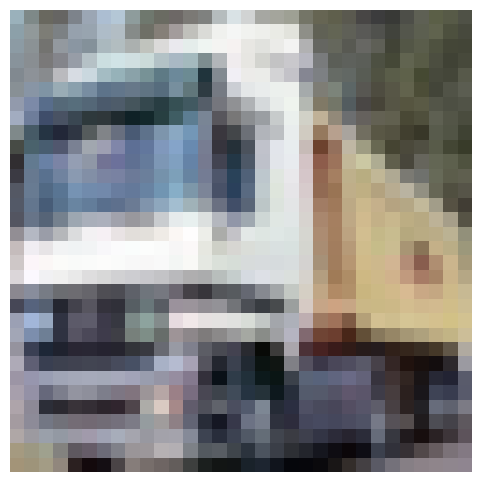

In [10]:
import matplotlib.pyplot as plt
print(y_train[1])

plt.figure(figsize=(6, 6))
plt.imshow(x_train[1])
plt.axis('off')
plt.show()

In [ ]:
model = keras.Sequential()
model.add(keras.layers.Conv2D(filters=32, kernel_size=(3, 3), activation="relu", input_shape=(32, 32, 3), padding="same"))
model.add(keras.layers.Conv2D(filters=32, kernel_size=(3, 3), activation="relu"))
model.add(keras.layers.MaxPool2D(pool_size=(2, 2)))

# add dropout 1:
model.add(keras.layers.Dropout(rate=0.25))

# add repeated layers
model.add(keras.layers.Conv2D(filters=32, kernel_size=(3, 3), activation="relu", padding="same"))
model.add(keras.layers.Conv2D(filters=32, kernel_size=(3, 3), activation="relu"))
model.add(keras.layers.MaxPool2D(pool_size=(2, 2)))
model.add(keras.layers.Dropout(rate=0.25))

model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(512, activation="relu"))

# add dropout 2:
model.add(keras.layers.Dropout(rate=0.50))

model.add(keras.layers.Dense(10, activation="softmax"))


model.compile(loss='sparse_categorical_crossentropy', optimizer=keras.optimizers.Adadelta(learning_rate=float(1)), metrics=['accuracy'])


In [17]:
history = model.fit(x_train, y_train, batch_size=32, epochs=20, verbose=1, validation_data=(x_test, y_test), shuffle=True)

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.3974 - loss: 1.6487 - val_accuracy: 0.5020 - val_loss: 1.3762
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.5512 - loss: 1.2554 - val_accuracy: 0.6075 - val_loss: 1.1168
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.6079 - loss: 1.1032 - val_accuracy: 0.6301 - val_loss: 1.0592
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.6431 - loss: 1.0069 - val_accuracy: 0.6918 - val_loss: 0.8756
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.6731 - loss: 0.9324 - val_accuracy: 0.6829 - val_loss: 0.9193
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.6911 - loss: 0.8850 - val_accuracy: 0.7111 - val_loss: 0.8286
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.7027 - loss: 0.8453 - val_accuracy: 0.7251 - val_loss: 0.7974
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.7132 -

---
## Question 1

Overfitting is a phenomena where the model is too complex for the data it is trying to represent. Instead of capturing the pattern in the data, the model is so sophisticated that it starts to model the noise in the data as well, called overfitting. In such cases, the model has captured the training data almost perfectly, while not generalizing well to other data. 

Dropout does exactly this, it turns some proportion of parameters off during training, reducing the number of parameters of the model a.k.a. reducing its complexity.

---


---

## Question 2:


Plot is included below

---

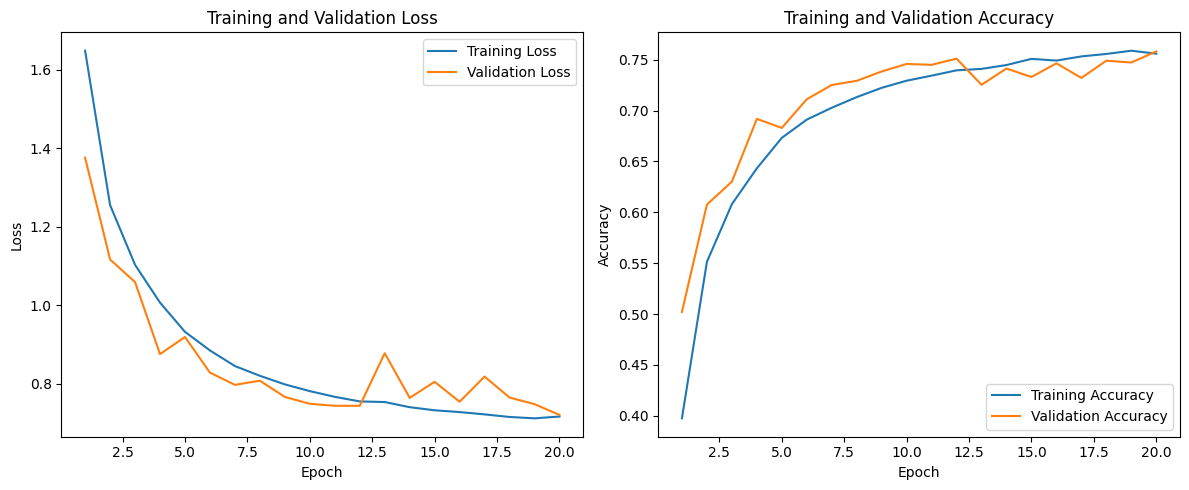

In [21]:
epochs = range(1, len(history.history['loss']) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(epochs, history.history['loss'], label='Training Loss')
plt.plot(epochs, history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(epochs, history.history['accuracy'], label='Training Accuracy')
plt.plot(epochs, history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

---
## Question 3:

- Training time per epoch of learning-based exercises 6 and 7; ~9 ms/step * 375 steps ~ **3.38 seconds**
- Training time per epoch of challenge-based model; ~13 ms/step * 1563 steps ~ **20.32 seconds**

## Question 4:
1. As shown in the computations, the epochs of the former model consisted of 375 steps and the latter model 1563 steps. 

2. Combined with the fact that the learning-based model trained for 6 epochs, and this new model for 20 epochs means the total training time increases from 24 seconds to 396 seconds i.e. 16.5x slower

---

In [ ]:
optimizer = keras.optimizers.RMSprop(learning_rate=float(0.0001), 
                                     weight_decay=1e-6)

model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=optimizer,
    metrics=["accuracy"]
)